Training Isolation Forest...


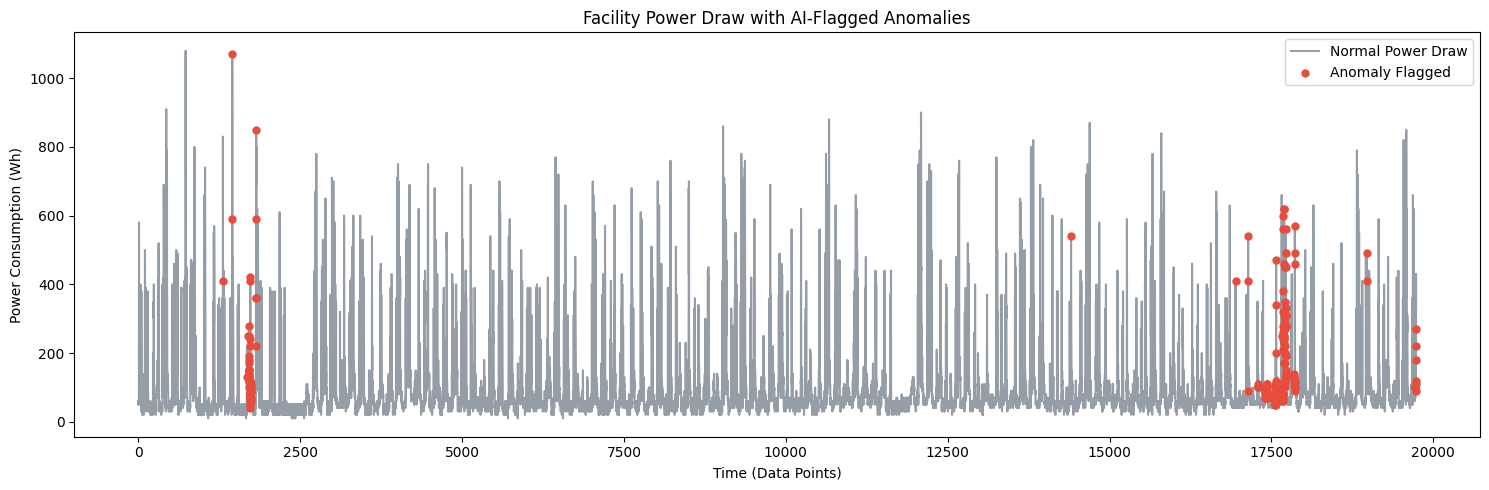

✅ Anomaly Model and Scaler securely saved!


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import joblib
import os

# 1. Load the data
df = pd.read_csv('../data/raw/energydata_complete.csv')

# 2. Prep the data
# We only want the numeric sensor columns. We ignore the 'date' for the math, 
# and drop 'rv1' and 'rv2' (random variables included in the raw dataset).
features = [col for col in df.columns if col not in ['date', 'rv1', 'rv2']]
X = df[features]

# 3. Scale the data
# Sensors measure in different units (temperature vs. watts). 
# We scale them so a huge number in watts doesn't overshadow a small change in temperature.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Train the Anomaly Detector
print("Training Isolation Forest...")
# contamination=0.01 means we are telling the AI: "Assume roughly 1% of this data is a severe anomaly"
iso_forest = IsolationForest(contamination=0.01, random_state=42)

# The model returns 1 for normal, and -1 for an anomaly
df['anomaly_status'] = iso_forest.fit_predict(X_scaled)

# 5. Visualize the anomalies
# Filter out the rows where the AI flagged an anomaly (-1)
anomalies = df[df['anomaly_status'] == -1]

plt.figure(figsize=(15, 5))
# Plotting the main power draw (Appliances column)
plt.plot(df.index, df['Appliances'], label='Normal Power Draw', color='#2c3e50', alpha=0.5)
# Putting red dots exactly where the AI flagged an anomaly
plt.scatter(anomalies.index, anomalies['Appliances'], color='#e74c3c', label='Anomaly Flagged', s=25, zorder=5)

plt.title('Facility Power Draw with AI-Flagged Anomalies')
plt.xlabel('Time (Data Points)')
plt.ylabel('Power Consumption (Wh)')
plt.legend()
plt.tight_layout()
plt.show()

# 6. Save the model and the scaler for the FastAPI backend
os.makedirs('../models', exist_ok=True)
joblib.dump(iso_forest, '../models/anomaly_model.pkl')
joblib.dump(scaler, '../models/energy_scaler.pkl') 
print("✅ Anomaly Model and Scaler securely saved!")